In this notebook, we carry out multi-output batch Bayesian optimization to attain a next proposal for the cement mixtures.

In [1]:
import pandas as pd
import torch
import botorch
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

In [2]:
%matplotlib inline
plt.rcParams['figure.figsize'] = [10, 8]
plt.rcParams['axes.facecolor'] = 'white'

## System Setup

This cell automatically configures the environment for both local development and CI.

In [3]:
# boxcrete resolves data paths relative to the package installation,
# so no working directory changes are needed.
# If running from source: pip install -e .

In [4]:
from boxcrete import utils

data_path = utils.DATA_PATH
data = utils.load_concrete_strength(data_path=data_path)

## Define and Fit Model
1. fit strength model
2. fit GWP model
3. unify as composition-input-only with fixed-time outputs

In [5]:
from boxcrete import models

In [6]:
model_strength_days = [1, 28]  # the strength days that are converted to optmization objectives
model = models.SustainableConcreteModel(strength_days=model_strength_days)

In [7]:
model.fit_gwp_model(data)

Bounds do not hold in training data: X_bounds[0, :], X.amin(dim=0) = (tensor([300.,   0.,   0.,  60.,   0.,   0., 600., 800.,   0.,   0.]), tensor([  0.0000,   0.0000,   0.0000,  43.0000,   0.0000,   0.0000, 423.0000,
          0.0000,   0.0000,   4.5000], dtype=torch.float64))X_bounds[1, :], X.amax(dim=0) = (tensor([7.0000e+02, 3.5000e+02, 4.5000e+02, 7.5000e+02, 1.5000e+02, 5.0000e+01,
        1.7000e+03, 1.9500e+03, 1.0000e+00, 4.0000e+01]), tensor([8.9467e+02, 5.3300e+02, 1.1987e+03, 4.4300e+02, 1.3330e+01, 0.0000e+00,
        2.3570e+03, 1.3560e+03, 1.0000e+00, 2.2000e+01], dtype=torch.float64))


SingleTaskGP(
  (likelihood): GaussianLikelihood(
    (noise_covar): HomoskedasticNoise(
      (raw_noise_constraint): LogTransformedInterval(1.000E-04, 1.000E+00)
    )
  )
  (mean_module): ZeroMean()
  (covar_module): LinearKernel(
    (raw_variance_constraint): Positive()
  )
)

In [8]:
model.fit_strength_model(data, use_fixed_noise=False)

SingleTaskGP(
  (likelihood): GaussianLikelihood(
    (noise_covar): HomoskedasticNoise(
      (raw_noise_constraint): LogTransformedInterval(1.000E-06, 1.000E+00)
    )
  )
  (mean_module): ConstantMean()
  (covar_module): AdditiveKernel(
    (kernels): ModuleList(
      (0): ScaleKernel(
        (base_kernel): MaternKernel(
          (raw_lengthscale_constraint): LogTransformedInterval(1.000E-02, 1.000E+03)
        )
        (raw_outputscale_constraint): LogTransformedInterval(1.000E-02, 1.000E+02)
      )
      (1): ScaleKernel(
        (base_kernel): RBFKernel(
          (raw_lengthscale_constraint): LogTransformedInterval(1.000E-02, 1.000E+03)
        )
        (raw_outputscale_constraint): LogTransformedInterval(1.000E-02, 1.000E+02)
      )
    )
  )
  (outcome_transform): Standardize()
  (input_transform): ChainedInputTransform(
    (tf1): AffineInputTransform()
    (tf2): Log10()
    (tf3): Normalize()
  )
)

In [9]:
model.strength_model.likelihood.noise

tensor([0.0310], dtype=torch.float64, grad_fn=<ExpBackward0>)

In [10]:
model_list = model.get_model_list()

In [11]:
# NOTE: the original search space bounds are not satisfied by some of the Ozinga data.
X, Y, Yvar, X_bounds = data.gwp_data
ind = range(len(X))
post_list = model_list.posterior(X)

Bounds do not hold in training data: X_bounds[0, :], X.amin(dim=0) = (tensor([300.,   0.,   0.,  60.,   0.,   0., 600., 800.,   0.,   0.]), tensor([  0.0000,   0.0000,   0.0000,  43.0000,   0.0000,   0.0000, 423.0000,
          0.0000,   0.0000,   4.5000], dtype=torch.float64))X_bounds[1, :], X.amax(dim=0) = (tensor([7.0000e+02, 3.5000e+02, 4.5000e+02, 7.5000e+02, 1.5000e+02, 5.0000e+01,
        1.7000e+03, 1.9500e+03, 1.0000e+00, 4.0000e+01]), tensor([8.9467e+02, 5.3300e+02, 1.1987e+03, 4.4300e+02, 1.3330e+01, 0.0000e+00,
        2.3570e+03, 1.3560e+03, 1.0000e+00, 2.2000e+01], dtype=torch.float64))


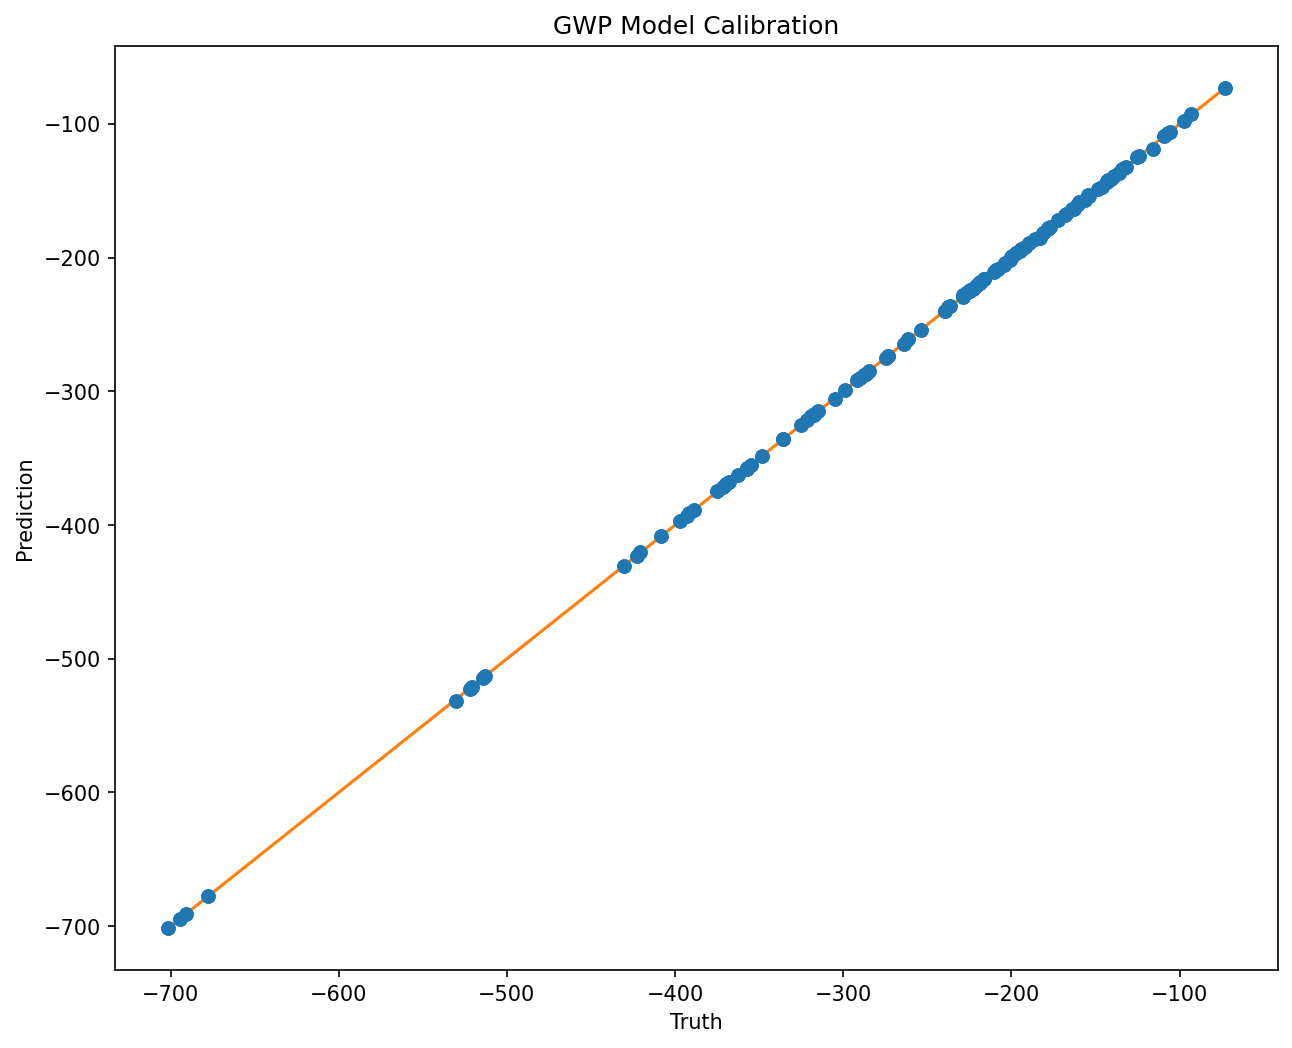

In [12]:
CHECK_gwp = True

if CHECK_gwp:
    obj_id = 0
    # Y[ind], post_list.mean[:, 0], Yvar[ind], post_list.variance[:, obj_id] # variance for GWP looking good, since it gets rounded to ~ 1%.
    truth = Y[ind]
    pred = post_list.mean[:, 0].detach()
    truth_std = Yvar[ind][ind].sqrt().detach()
    pred_std = post_list.variance[:, obj_id].sqrt().detach()
    plt.figure(dpi=150)
    plt.title("GWP Model Calibration")
    plt.ylabel("Prediction")
    plt.xlabel("Truth")
    plt.scatter(truth, pred)
    plt.errorbar(truth, pred, yerr=2*pred_std, fmt="o")
    line = torch.arange(truth.min(), truth.max())
    plt.plot(line, line)
    plt.show()

In [13]:
# Quick check: predict GWP for first composition in the dataset
X_gwp = data.gwp_data[0]  # compositions without Time
model.gwp_model.posterior(X_gwp[:1]).mean

Bounds do not hold in training data: X_bounds[0, :], X.amin(dim=0) = (tensor([300.,   0.,   0.,  60.,   0.,   0., 600., 800.,   0.,   0.]), tensor([  0.0000,   0.0000,   0.0000,  43.0000,   0.0000,   0.0000, 423.0000,
          0.0000,   0.0000,   4.5000], dtype=torch.float64))X_bounds[1, :], X.amax(dim=0) = (tensor([7.0000e+02, 3.5000e+02, 4.5000e+02, 7.5000e+02, 1.5000e+02, 5.0000e+01,
        1.7000e+03, 1.9500e+03, 1.0000e+00, 4.0000e+01]), tensor([8.9467e+02, 5.3300e+02, 1.1987e+03, 4.4300e+02, 1.3330e+01, 0.0000e+00,
        2.3570e+03, 1.3560e+03, 1.0000e+00, 2.2000e+01], dtype=torch.float64))


tensor([[-321.7353]], dtype=torch.float64, grad_fn=<UnsqueezeBackward0>)

In [14]:
model.strength_model.likelihood.noise

tensor([0.0310], dtype=torch.float64, grad_fn=<ExpBackward0>)

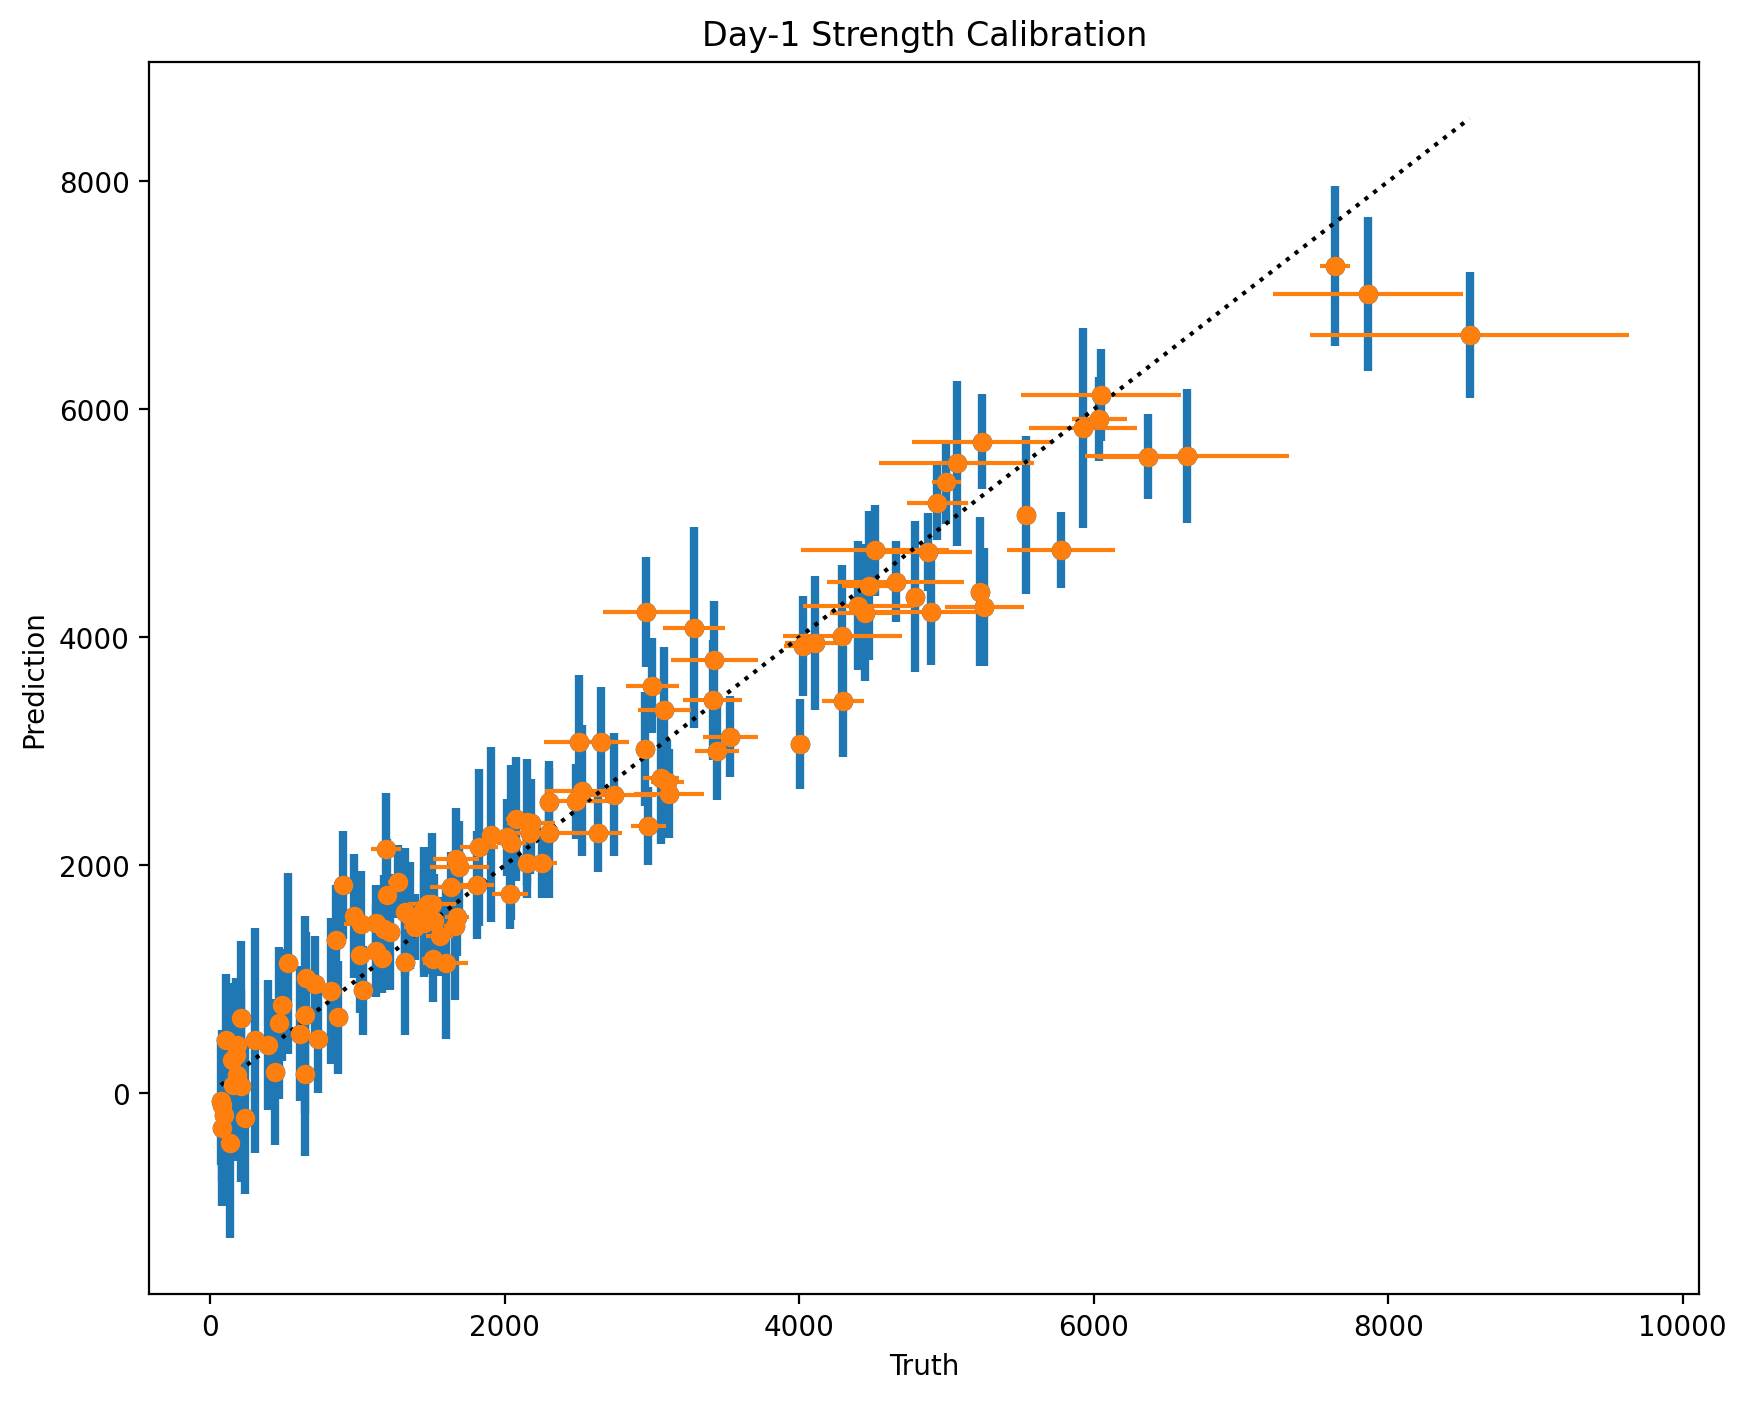

In [15]:
CHECK_1day = True

if CHECK_1day:
    time = 1
    Xt, truth, truth_var = data.strength_data_by_time(time)
    truth = truth.squeeze()
    truth_std = truth_var.sqrt().squeeze()
    post_t = model.strength_model.posterior(Xt)
    pred = post_t.mean.detach().squeeze()
    pred_std = post_t.variance.sqrt().detach().squeeze()

    fig = plt.figure(dpi=200)
    plt.title(f"Day-{time} Strength Calibration")
    plt.ylabel("Prediction")
    plt.xlabel("Truth")
    plt.scatter(truth, pred)
    lw = 3
    plt.errorbar(truth, pred, yerr=2 * pred_std, fmt="o", linewidth=lw)
    plt.errorbar(truth.squeeze(), pred, xerr=2 * truth_std.squeeze(), fmt="o", linewidth=lw/2)
    line = torch.arange(truth.min(), truth.max())
    plt.plot(line, line, color="black", linestyle=":")
    plt.show()

In [16]:
# fig.savefig("1_day_strength_callibration_fourth_batch.pdf", bbox_inches='tight')

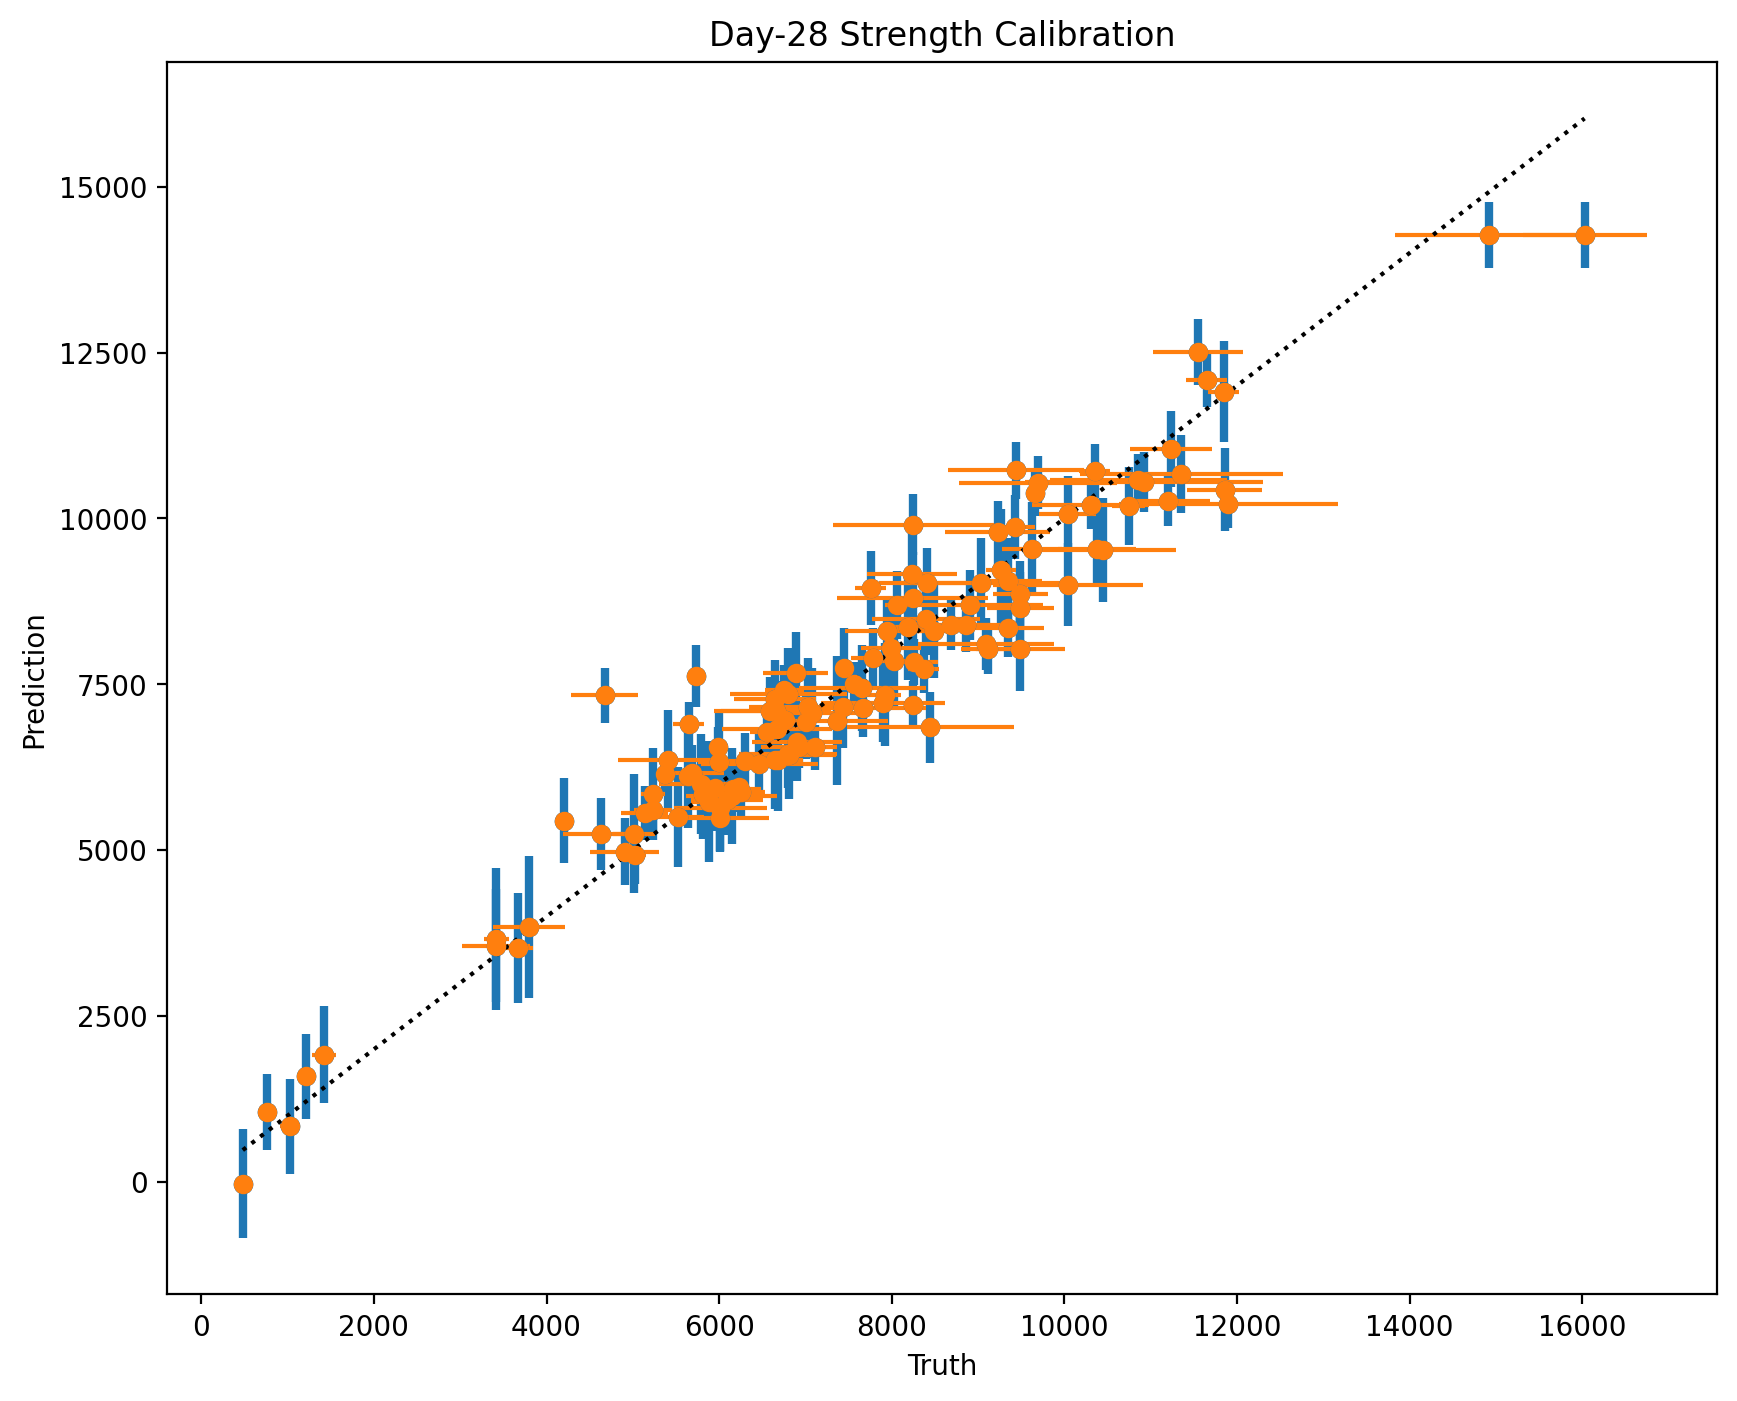

In [17]:
time = 28
Xt, truth, truth_var = data.strength_data_by_time(time)
truth = truth.squeeze()
truth_std = truth_var.sqrt().squeeze()

post_t = model.strength_model.posterior(Xt)
pred = post_t.mean.detach().squeeze()
pred_std = post_t.variance.sqrt().detach().squeeze()

fig = plt.figure(dpi=200)
plt.title(f"Day-{time} Strength Calibration")
plt.ylabel("Prediction")
plt.xlabel("Truth")
plt.scatter(truth, pred)
lw = 3
plt.errorbar(truth, pred, yerr=2 * pred_std, fmt="o", linewidth=lw)
plt.errorbar(truth, pred, xerr=2 * truth_std, fmt="o", linewidth=lw/2)
line = torch.arange(truth.min(), truth.max())
plt.plot(line, line, color="black", linestyle=":")
plt.show()

In [18]:
# fig.savefig("28_day_strength_callibration_fourth_batch.pdf", bbox_inches='tight')

## Strength Curve Predictions

In [19]:
## Example 1: Select a mix in the data set that we want to plot
X = data.gwp_data[0]
mix_ind = 21  # this selects which mix from the database we want to plot
X_plot = X[[mix_ind]].clone()

## Example 2: manually specify the composition
manual_specify = True
if manual_specify:
    cols = data.X_columns[:-1]  # composition columns (without Time)
    X_plot[0, cols.index("Cement (kg/m3)")] = 210.0
    X_plot[0, cols.index("Fly Ash (kg/m3)")] = 110.0
    X_plot[0, cols.index("Slag (kg/m3)")] = 180.0
    X_plot[0, cols.index("Water (kg/m3)")] = 180.0
    X_plot[0, cols.index("HRWR (kg/m3)")] = 2.0
    X_plot[0, cols.index("Fine Aggregate (kg/m3)")] = 1400.0

# Print the mix composition
print("== mix tested ==")
for col in cols:
    print(f"  {col}: {X_plot[0, cols.index(col)].item():.1f}")
binder = sum(X_plot[0, cols.index(c)].item() for c in ["Cement (kg/m3)", "Fly Ash (kg/m3)", "Slag (kg/m3)"])
if binder > 0:
    print(f"  w/b ratio: {X_plot[0, cols.index('Water (kg/m3)')].item() / binder:.3f}")

Bounds do not hold in training data: X_bounds[0, :], X.amin(dim=0) = (tensor([300.,   0.,   0.,  60.,   0.,   0., 600., 800.,   0.,   0.]), tensor([  0.0000,   0.0000,   0.0000,  43.0000,   0.0000,   0.0000, 423.0000,
          0.0000,   0.0000,   4.5000], dtype=torch.float64))X_bounds[1, :], X.amax(dim=0) = (tensor([7.0000e+02, 3.5000e+02, 4.5000e+02, 7.5000e+02, 1.5000e+02, 5.0000e+01,
        1.7000e+03, 1.9500e+03, 1.0000e+00, 4.0000e+01]), tensor([8.9467e+02, 5.3300e+02, 1.1987e+03, 4.4300e+02, 1.3330e+01, 0.0000e+00,
        2.3570e+03, 1.3560e+03, 1.0000e+00, 2.2000e+01], dtype=torch.float64))


== mix tested ==
  Cement (kg/m3): 210.0
  Fly Ash (kg/m3): 110.0
  Slag (kg/m3): 180.0
  Water (kg/m3): 180.0
  HRWR (kg/m3): 2.0
  MRWR (kg/m3): 0.0
  Fine Aggregate (kg/m3): 1400.0
  Coarse Aggregates (kg/m3): 0.0
  Material Source: 0.0
  Temp (C): 22.0
  w/b ratio: 0.360


== mix tested ==
  Cement (kg/m3): 210.0
  Fly Ash (kg/m3): 110.0
  Slag (kg/m3): 180.0
  Water (kg/m3): 180.0
  HRWR (kg/m3): 2.0
  MRWR (kg/m3): 0.0
  Fine Aggregate (kg/m3): 1400.0
  Coarse Aggregates (kg/m3): 0.0
  Material Source: 0.0
  Temp (C): 22.0


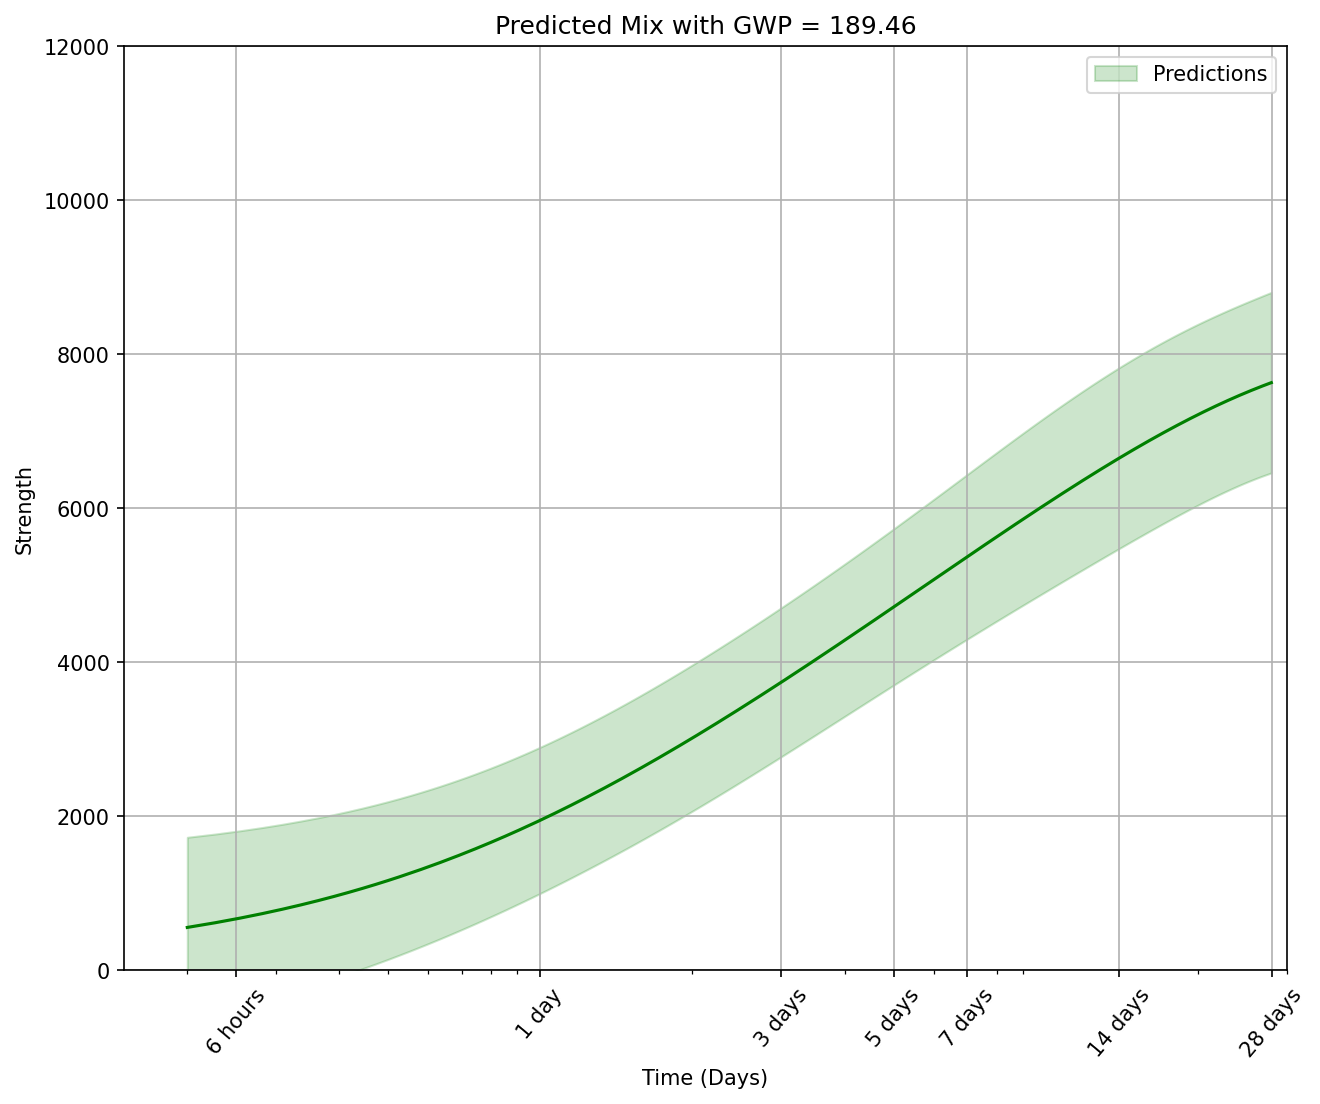

<Figure size 600x600 with 0 Axes>

In [20]:
## Run GWP and strength curve predictions
gwp_pred = model.gwp_model.posterior(X_plot).mean

t_start, t_stop = 0.2, 28.0
num_t = 1024    # default value is 1024
plot_times = torch.arange(t_start, t_stop, step=(t_stop - t_start) / num_t)

#plot_times = torch.tensor([0.2, 0.3, 0.5, 0.8, 1.0, 2.0, 3.0, 5.0, 28.0])
#num_t = plot_times.size(dim=0)

# adding time dimension to composition inputs
X_w_time = torch.cat(
    (X_plot.expand(num_t, X_plot.shape[-1]), plot_times.unsqueeze(-1)), dim=-1
)

curve_post = model.strength_model.posterior(X_w_time)
curve_mean = curve_post.mean.detach().squeeze()
curve_std = curve_post.variance.sqrt().detach().squeeze()

# print the mix composition
cols = data.X_columns[:-1]
print('== mix tested ==')
for col in cols:
    print(f'  {col}: {X_plot[0, cols.index(col)].item():.1f}')



## Generate plot
color_1 = "green"
fig = plt.figure(dpi=150)
plt.title(f"Predicted Mix with GWP = {-gwp_pred.round(decimals=2).item()}")
plt.plot(plot_times, curve_mean, color=color_1)
plt.ylabel("Strength")
plt.xlabel("Time (Days)")
nsigma = 2
# plot uncertainties or not
plot_uncertainties = 1;
if plot_uncertainties == 1:
    plt.fill_between(
        plot_times,
        curve_mean - nsigma * curve_std,
        curve_mean + nsigma * curve_std,
        alpha=0.2,
        label="Predictions",
        color=color_1,
    )

# if the mix is in the dataset, could grab the observed strength data ("observed_data") from Y
# plt.plot(observed_times, observed_data, "o", label="Observations", c=color_1)
plt.legend()

plt.xscale("log")
special_times = [6 / 24, 1, 3, 5, 7, 14, 28]
special_labels = [
    "6 hours",
    "1 day",
    "3 days",
    "5 days",
    "7 days",
    "14 days",
    "28 days",
]
plt.xticks(special_times, special_labels, rotation=50)
plt.grid(visible=True)

xlim = (0.15, 30)
ylim = (0, 12000)
plt.xlim(xlim)
plt.ylim(ylim)
plt.figure(figsize=(6,6))
plt.show()